<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/valuechain/early_phase_subsurface_to_flow_assurance_handoff.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# From ECLIPSE/OPM to NeqSim: an early-phase subsurface-to-flow-assurance handoff

**Purpose.** Demonstrate a repeatable, one-button workflow that moves reservoir-simulation
results into well, SURF, choke, MPFM, flow-assurance, and reporting calculations without
manual Excel shuffling.

**Audience.** Reservoir, well, flow-assurance, production-technology, and process engineers
working together in early field-development phases.

**What is real in this notebook.** The data adapter, schema, validation, scenario selection,
NeqSim thermodynamics, representative well calculation, native `TwoFluidPipe` flowline,
Beggs-and-Brill verification, hydrate-equilibrium calculation, choke sizing, output contracts,
hashes, and report-ready package are executable. The reservoir profiles are deliberately
synthetic and public so the notebook contains no proprietary field data.

**Important limitation.** This is an educational screening workflow, not a certified well,
flow-assurance, metering, or facility design. Replace the synthetic inputs, geometry, fluid,
and project acceptance limits before using the pattern on a real development.


In [1]:
import importlib.metadata
import os
from pathlib import Path
import subprocess
import sys


os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim_early_phase_matplotlib")
REQUIRED_PACKAGES = {
    "neqsim": "3.17.0",
}


def installed_version(package_name):
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return None


missing_packages = [
    f"{name}=={version}"
    for name, version in REQUIRED_PACKAGES.items()
    if installed_version(name) != version
]
if missing_packages:
    install = subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *missing_packages,
        ],
        capture_output=True,
        text=True,
        timeout=1200,
    )
    if install.returncode != 0:
        print(install.stdout)
        print(install.stderr)
        raise RuntimeError("Dependency installation failed.")

print(
    {
        "Python": sys.version.split()[0],
        "NeqSim Python bridge": installed_version("neqsim"),
    }
)


{'Python': '3.12.13', 'NeqSim Python bridge': '3.17.0'}


## Learning objectives

After running the notebook, you should be able to:

1. read ECLIPSE/OPM summary vectors through `res2df` without an Excel intermediate;
2. normalize vectors, dates, units, identities, geometry, and fluid data into one contract;
3. reject incomplete or inconsistent input before simulation starts;
4. preserve a coherent reservoir realization through every downstream calculation;
5. run a representative NeqSim well and native two-fluid flowline calculation;
6. create choke, MPFM, topside-arrival, and flow-assurance handoffs automatically; and
7. organize deterministic calculations as contracts for specialized engineering agents.


In [2]:
import hashlib
import json
import math
import platform
import shutil
from zipfile import ZIP_DEFLATED, ZipFile

from IPython.display import display
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)
RANDOM_SEED = 20260821
rng = np.random.default_rng(RANDOM_SEED)
ARTIFACT_DIRECTORY = Path("early_phase_handoff_artifacts")
ARTIFACT_DIRECTORY.mkdir(exist_ok=True)
print(f"Artifact directory: {ARTIFACT_DIRECTORY.resolve()}")


Artifact directory: /workspace/scratch/01d080ccdf30/early_phase_handoff_artifacts


## 1. Target workflow

The handoff is a governed data product, not a collection of copied cells. Each stage receives
versioned tables and returns results plus validation evidence. AI agents can coordinate the
stages, but physical calculations and acceptance checks remain deterministic and auditable.


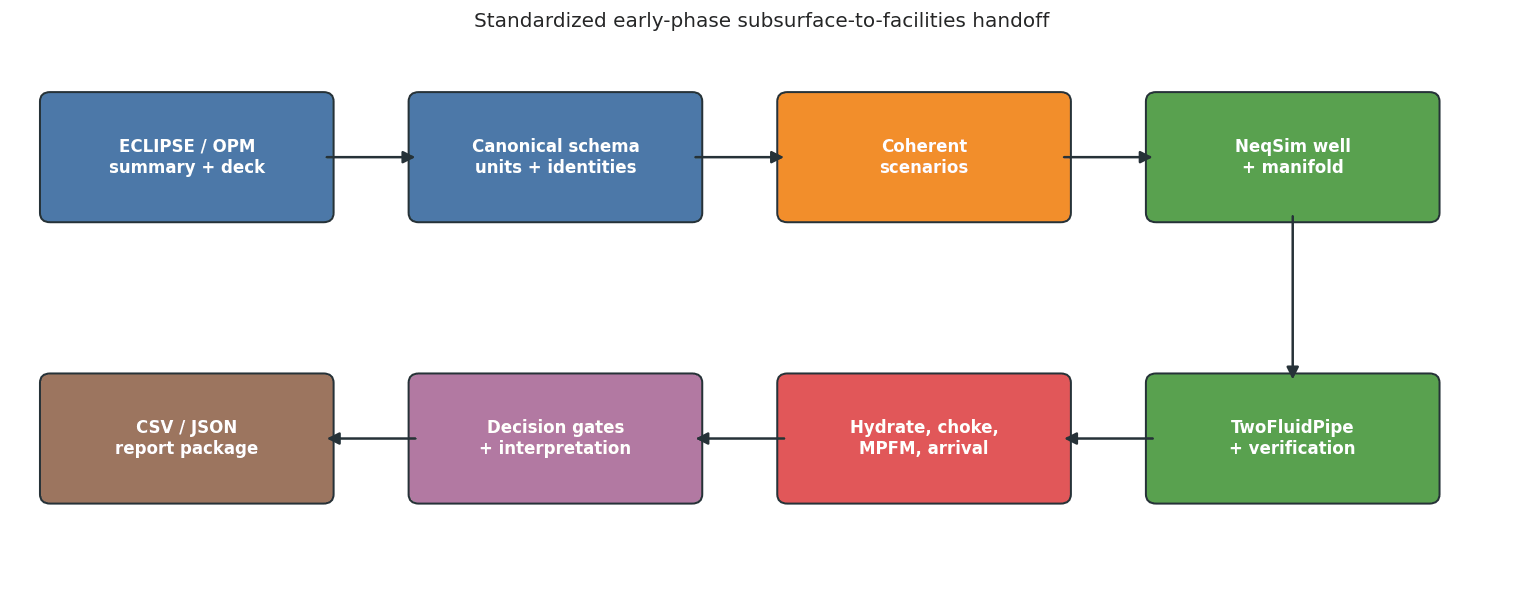

In [3]:
workflow_nodes = [
    (0.3, 3.2, "ECLIPSE / OPM\nsummary + deck", "#4C78A8"),
    (3.2, 3.2, "Canonical schema\nunits + identities", "#4C78A8"),
    (6.1, 3.2, "Coherent\nscenarios", "#F28E2B"),
    (9.0, 3.2, "NeqSim well\n+ manifold", "#59A14F"),
    (9.0, 0.8, "TwoFluidPipe\n+ verification", "#59A14F"),
    (6.1, 0.8, "Hydrate, choke,\nMPFM, arrival", "#E15759"),
    (3.2, 0.8, "Decision gates\n+ interpretation", "#B279A2"),
    (0.3, 0.8, "CSV / JSON\nreport package", "#9C755F"),
]
figure, axis = plt.subplots(figsize=(12.8, 5.1))
axis.set(xlim=(0.0, 11.8), ylim=(0.0, 4.7))
axis.axis("off")
for x_position, y_position, label, color in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, y_position),
        2.15,
        0.95,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="#263238",
        linewidth=1.2,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 1.075,
        y_position + 0.475,
        label,
        color="white",
        ha="center",
        va="center",
        weight="bold",
    )
arrow_edges = [
    ((2.45, 3.675), (3.2, 3.675)),
    ((5.35, 3.675), (6.1, 3.675)),
    ((8.25, 3.675), (9.0, 3.675)),
    ((10.075, 3.2), (10.075, 1.75)),
    ((9.0, 1.275), (8.25, 1.275)),
    ((6.1, 1.275), (5.35, 1.275)),
    ((3.2, 1.275), (2.45, 1.275)),
]
for start, end in arrow_edges:
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.5,
            color="#263238",
        )
    )
axis.set_title("Standardized early-phase subsurface-to-facilities handoff")
figure.tight_layout()
workflow_figure_path = ARTIFACT_DIRECTORY / "workflow_handoff.png"
figure.savefig(workflow_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 2. The minimum data contract

A production profile alone is insufficient. The receiving model also needs identities, units,
pressure convention, fluid basis, well and route geometry, and uncertainty provenance.

The contract below uses absolute pressure and explicitly distinguishes standard-volume rates
from actual-volume rates. The realization is never discarded. For a realization $r$, the
cumulative oil used for ranking is

$$N_p(r,t)=\sum_i q_o(r,t_i)\Delta t_i$$

Selecting one actual realization near a target percentile preserves correlations among rate,
pressure, GOR, water breakthrough, and well contributions. Constructing a scenario from
independent percentiles of each column would generally create a case that never existed in the
reservoir ensemble.


In [4]:
VECTOR_CONTRACT = pd.DataFrame(
    [
        ("FOPR", "oil_rate_sm3_day", "Sm3/day", "field"),
        ("FGPR", "gas_rate_sm3_day", "Sm3/day", "field"),
        ("FWPR", "water_rate_sm3_day", "Sm3/day", "field"),
        ("FPR", "reservoir_pressure_bara", "bara", "field"),
        ("WOPR:*", "well_oil_rate_sm3_day", "Sm3/day", "well"),
        ("WGPR:*", "well_gas_rate_sm3_day", "Sm3/day", "well"),
        ("WWPR:*", "well_water_rate_sm3_day", "Sm3/day", "well"),
        ("WBHP:*", "bottomhole_pressure_bara", "bara", "well"),
    ],
    columns=["source_vector", "canonical_name", "unit", "scope"],
)
REQUIRED_IDENTITY = pd.DataFrame(
    [
        ("schema_version", "Version of this handoff contract"),
        ("case_id", "Reservoir model and forecast identity"),
        ("realization_id", "Uncertainty realization retained end to end"),
        ("report_date", "Simulator report date"),
        ("source_revision", "Immutable source revision or model tag"),
        ("fluid_id", "Compositional/PVT model identity"),
        ("geometry_id", "Well and SURF geometry revision"),
        ("pressure_basis", "Absolute or gauge; this contract requires absolute"),
    ],
    columns=["field", "meaning"],
)
display(VECTOR_CONTRACT)
display(REQUIRED_IDENTITY)


,source_vector,canonical_name,unit,scope
0,FOPR,oil_rate_sm3_day,Sm3/day,field
1,FGPR,gas_rate_sm3_day,Sm3/day,field
2,FWPR,water_rate_sm3_day,Sm3/day,field
3,FPR,reservoir_pressure_bara,bara,field
4,WOPR:*,well_oil_rate_sm3_day,Sm3/day,well
5,WGPR:*,well_gas_rate_sm3_day,Sm3/day,well
6,WWPR:*,well_water_rate_sm3_day,Sm3/day,well
7,WBHP:*,bottomhole_pressure_bara,bara,well


,field,meaning
0,schema_version,Version of this handoff contract
1,case_id,Reservoir model and forecast identity
2,realization_id,Uncertainty realization retained end to end
3,report_date,Simulator report date
4,source_revision,Immutable source revision or model tag
5,fluid_id,Compositional/PVT model identity
6,geometry_id,Well and SURF geometry revision
7,pressure_basis,Absolute or gauge; this contract requires abso...


## 3. Adapter for a real ECLIPSE or OPM Flow case

[`res2df`](https://equinor.github.io/res2df/introduction.html) wraps `resdata` and `opm.io`
and can extract `.SMSPEC/.UNSMRY` summary vectors directly to a pandas DataFrame. The official
API accepts a `ResdataFiles` object, vector names or wildcards, and a time index.

The function below is deliberately defined but not called because this public notebook does not
contain proprietary simulator files. On a real case, provide the `.DATA` path or case basename.
Install the optional reader with `pip install res2df` in an environment where its license and
platform support have been reviewed.


In [5]:
def read_eclipse_summary_with_res2df(
    data_file,
    realization_id,
    source_revision,
):
    import res2df

    requested_vectors = [
        "FOPR",
        "FGPR",
        "FWPR",
        "FPR",
        "WOPR:*",
        "WGPR:*",
        "WWPR:*",
        "WBHP:*",
    ]
    reservoir_files = res2df.ResdataFiles(str(data_file))
    frame = res2df.summary.df(
        reservoir_files,
        time_index="monthly",
        column_keys=requested_vectors,
        datetime=True,
    ).reset_index()
    frame = frame.rename(columns={"DATE": "report_date"})
    frame["realization_id"] = int(realization_id)
    frame["source_revision"] = str(source_revision)
    frame["source_file"] = str(data_file)
    return frame


print("Real-case adapter defined; the public example continues with synthetic data.")


Real-case adapter defined; the public example continues with synthetic data.


## 4. Public synthetic ECLIPSE-style ensemble

The next cell creates 24 correlated reservoir realizations. The column names match common
summary vectors, so the downstream normalization does not know whether the source was `res2df`
or the generator. Three wells contribute to field totals. Capacity, decline, pressure support,
GOR, water breakthrough, and allocation vary together within each realization.


In [6]:
CASE_ID = "PUBLIC-EARLY-PHASE-DEMO"
SOURCE_REVISION = "synthetic-eclipse-summary-v1"
START_DATE = pd.Timestamp("2027-01-01")
DATES = pd.date_range(START_DATE, periods=49, freq="MS")
REALIZATIONS = 24
WELL_NAMES = ["W1", "W2", "W3"]
rows = []

for realization_id in range(REALIZATIONS):
    capacity_factor = rng.lognormal(mean=0.0, sigma=0.13)
    decline_per_year = np.clip(rng.normal(0.16, 0.025), 0.09, 0.24)
    pressure_support = rng.normal(1.0, 0.10)
    initial_gor = rng.normal(215.0, 18.0)
    water_breakthrough_year = rng.normal(2.25, 0.45)
    allocation = rng.dirichlet([4.0, 3.4, 2.8])

    for report_date in DATES:
        time_year = (report_date - START_DATE).days / 365.25
        water_growth = 1.0 / (
            1.0 + np.exp(-2.4 * (time_year - water_breakthrough_year))
        )
        oil_rate = (
            4700.0
            * capacity_factor
            * np.exp(-decline_per_year * time_year)
            * (1.0 - 0.22 * water_growth)
        )
        gor = initial_gor * (1.0 + 0.16 * time_year / 4.0)
        gas_rate = oil_rate * gor
        water_rate = 140.0 + 3300.0 * water_growth * capacity_factor
        pressure = (
            318.0
            - (12.0 / pressure_support) * time_year
            - 5.0 * water_growth
        )
        row = {
            "DATE": report_date,
            "REALIZATION": realization_id,
            "FOPR": oil_rate,
            "FGPR": gas_rate,
            "FWPR": water_rate,
            "FPR": pressure,
        }
        for well_index, well_name in enumerate(WELL_NAMES):
            cyclic_shift = 1.0 + 0.03 * np.sin(
                2.0 * np.pi * time_year / 2.0 + well_index
            )
            well_share = allocation[well_index] * cyclic_shift
            raw_shares = allocation * (
                1.0
                + 0.03
                * np.sin(
                    2.0 * np.pi * time_year / 2.0
                    + np.arange(len(WELL_NAMES))
                )
            )
            normalized_share = well_share / raw_shares.sum()
            drawdown = (
                36.0
                + 10.0 * normalized_share
                + 7.0 * water_growth
            )
            row[f"WOPR:{well_name}"] = oil_rate * normalized_share
            row[f"WGPR:{well_name}"] = gas_rate * normalized_share
            row[f"WWPR:{well_name}"] = water_rate * normalized_share
            row[f"WBHP:{well_name}"] = pressure - drawdown
        rows.append(row)

eclipse_summary = pd.DataFrame(rows)
eclipse_summary = eclipse_summary.sort_values(
    ["REALIZATION", "DATE"]
).reset_index(drop=True)
print(
    {
        "rows": len(eclipse_summary),
        "realizations": eclipse_summary["REALIZATION"].nunique(),
        "first_date": eclipse_summary["DATE"].min().date().isoformat(),
        "last_date": eclipse_summary["DATE"].max().date().isoformat(),
    }
)
display(eclipse_summary.head(4).round(2))


{'rows': 1176, 'realizations': 24, 'first_date': '2027-01-01', 'last_date': '2031-01-01'}


,DATE,REALIZATION,FOPR,FGPR,FWPR,FPR,WOPR:W1,WGPR:W1,WWPR:W1,WBHP:W1,WOPR:W2,WGPR:W2,WWPR:W2,WBHP:W2,WOPR:W3,WGPR:W3,WWPR:W3,WBHP:W3
0,2027-01-01,0,6518.36,1381893.97,148.63,317.99,2287.20,484885.83,52.15,278.47,3584.20,759850.22,81.73,276.48,646.97,137157.92,14.75,280.98
1,2027-02-01,0,6437.94,1369478.11,150.58,317.16,2267.37,482314.15,53.03,277.62,3536.88,752363.93,82.72,275.65,633.70,134800.03,14.82,280.15
2,2027-03-01,0,6366.04,1358321.94,152.71,316.40,2251.20,480337.57,54.00,276.84,3493.02,745304.49,83.79,274.89,621.83,132679.88,14.92,279.40
3,2027-04-01,0,6287.22,1346029.34,155.57,315.56,2234.52,478387.36,55.29,275.99,3443.56,737230.89,85.21,274.06,609.14,130411.09,15.07,278.57


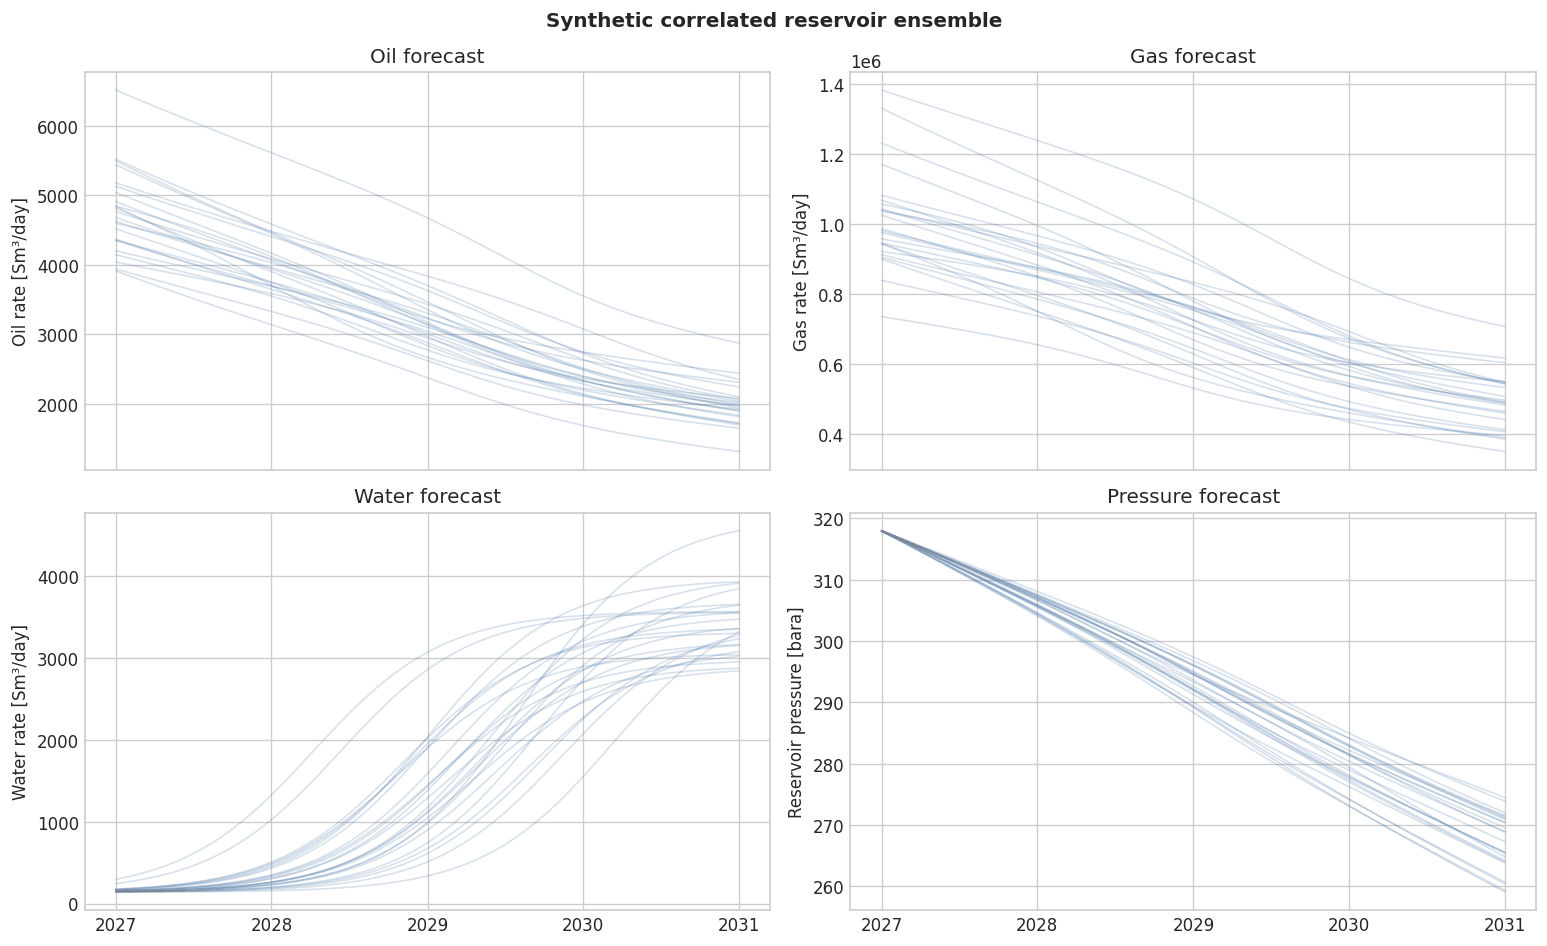

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(13.0, 8.0), sharex=True)
plot_specs = [
    ("FOPR", "Oil rate [Sm³/day]", "Oil forecast"),
    ("FGPR", "Gas rate [Sm³/day]", "Gas forecast"),
    ("FWPR", "Water rate [Sm³/day]", "Water forecast"),
    ("FPR", "Reservoir pressure [bara]", "Pressure forecast"),
]
for axis, (column, ylabel, title) in zip(axes.flat, plot_specs):
    for _, realization in eclipse_summary.groupby("REALIZATION"):
        axis.plot(
            realization["DATE"],
            realization[column],
            color="#4C78A8",
            alpha=0.22,
            linewidth=1.0,
        )
    axis.set(ylabel=ylabel, title=title)
    axis.xaxis.set_major_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
figure.suptitle("Synthetic correlated reservoir ensemble", weight="bold")
figure.tight_layout()
ensemble_figure_path = ARTIFACT_DIRECTORY / "ensemble_profiles.png"
figure.savefig(ensemble_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 5. Normalize once, validate once

The normalized table is the only reservoir-rate table downstream tools receive. It records the
unit basis in the column names and carries source, fluid, and geometry identities on every row.
Well vectors remain available for representative-well and allocation calculations.


In [8]:
canonical_summary = eclipse_summary.rename(
    columns={
        "DATE": "report_date",
        "REALIZATION": "realization_id",
        "FOPR": "oil_rate_sm3_day",
        "FGPR": "gas_rate_sm3_day",
        "FWPR": "water_rate_sm3_day",
        "FPR": "reservoir_pressure_bara",
    }
).copy()
canonical_summary["schema_version"] = "1.0"
canonical_summary["case_id"] = CASE_ID
canonical_summary["source_revision"] = SOURCE_REVISION
canonical_summary["fluid_id"] = "PUBLIC-SRK-WELLSTREAM-v1"
canonical_summary["geometry_id"] = "DEMO-WELL-SURF-v1"
canonical_summary["pressure_basis"] = "absolute"
canonical_summary["reservoir_temperature_C"] = 90.0
canonical_summary["source_file"] = "synthetic://eclipse-summary-compatible"

canonical_columns = [
    "schema_version",
    "case_id",
    "realization_id",
    "report_date",
    "source_revision",
    "fluid_id",
    "geometry_id",
    "pressure_basis",
    "oil_rate_sm3_day",
    "gas_rate_sm3_day",
    "water_rate_sm3_day",
    "reservoir_pressure_bara",
    "reservoir_temperature_C",
    "source_file",
]
well_columns = [
    column
    for column in canonical_summary.columns
    if column.startswith(("WOPR:", "WGPR:", "WWPR:", "WBHP:"))
]
canonical_summary = canonical_summary[canonical_columns + well_columns]
display(canonical_summary.head(4).round(2))


,schema_version,case_id,realization_id,report_date,source_revision,fluid_id,geometry_id,pressure_basis,oil_rate_sm3_day,gas_rate_sm3_day,water_rate_sm3_day,reservoir_pressure_bara,reservoir_temperature_C,source_file,WOPR:W1,WGPR:W1,WWPR:W1,WBHP:W1,WOPR:W2,WGPR:W2,WWPR:W2,WBHP:W2,WOPR:W3,WGPR:W3,WWPR:W3,WBHP:W3
0,1.0,PUBLIC-EARLY-PHASE-DEMO,0,2027-01-01,synthetic-eclipse-summary-v1,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,absolute,6518.36,1381893.97,148.63,317.99,90.0,synthetic://eclipse-summary-compatible,2287.20,484885.83,52.15,278.47,3584.20,759850.22,81.73,276.48,646.97,137157.92,14.75,280.98
1,1.0,PUBLIC-EARLY-PHASE-DEMO,0,2027-02-01,synthetic-eclipse-summary-v1,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,absolute,6437.94,1369478.11,150.58,317.16,90.0,synthetic://eclipse-summary-compatible,2267.37,482314.15,53.03,277.62,3536.88,752363.93,82.72,275.65,633.70,134800.03,14.82,280.15
2,1.0,PUBLIC-EARLY-PHASE-DEMO,0,2027-03-01,synthetic-eclipse-summary-v1,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,absolute,6366.04,1358321.94,152.71,316.40,90.0,synthetic://eclipse-summary-compatible,2251.20,480337.57,54.00,276.84,3493.02,745304.49,83.79,274.89,621.83,132679.88,14.92,279.40
3,1.0,PUBLIC-EARLY-PHASE-DEMO,0,2027-04-01,synthetic-eclipse-summary-v1,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,absolute,6287.22,1346029.34,155.57,315.56,90.0,synthetic://eclipse-summary-compatible,2234.52,478387.36,55.29,275.99,3443.56,737230.89,85.21,274.06,609.14,130411.09,15.07,278.57


In [9]:
well_oil_columns = [f"WOPR:{name}" for name in WELL_NAMES]
well_gas_columns = [f"WGPR:{name}" for name in WELL_NAMES]
well_water_columns = [f"WWPR:{name}" for name in WELL_NAMES]
key_columns = ["case_id", "realization_id", "report_date"]
qc_checks = {
    "unique case-realization-date key": (
        ~canonical_summary.duplicated(key_columns).any()
    ),
    "required values populated": (
        canonical_summary[canonical_columns].notna().all().all()
    ),
    "rates are non-negative": (
        canonical_summary[
            [
                "oil_rate_sm3_day",
                "gas_rate_sm3_day",
                "water_rate_sm3_day",
            ]
        ].ge(0.0).all().all()
    ),
    "absolute pressure is physical": (
        canonical_summary["reservoir_pressure_bara"].gt(1.0).all()
    ),
    "pressure basis is explicit": (
        canonical_summary["pressure_basis"].eq("absolute").all()
    ),
    "field oil equals well sum": np.allclose(
        canonical_summary[well_oil_columns].sum(axis=1),
        canonical_summary["oil_rate_sm3_day"],
        rtol=1.0e-10,
    ),
    "field gas equals well sum": np.allclose(
        canonical_summary[well_gas_columns].sum(axis=1),
        canonical_summary["gas_rate_sm3_day"],
        rtol=1.0e-10,
    ),
    "field water equals well sum": np.allclose(
        canonical_summary[well_water_columns].sum(axis=1),
        canonical_summary["water_rate_sm3_day"],
        rtol=1.0e-10,
    ),
    "all realizations cover every date": (
        canonical_summary.groupby("realization_id")["report_date"]
        .nunique()
        .eq(len(DATES))
        .all()
    ),
}
data_qc = pd.DataFrame(
    {"check": qc_checks.keys(), "passed": qc_checks.values()}
)
display(data_qc)
if not data_qc["passed"].all():
    raise AssertionError(
        data_qc.loc[~data_qc["passed"], "check"].tolist()
    )


,check,passed
0,unique case-realization-date key,True
1,required values populated,True
2,rates are non-negative,True
3,absolute pressure is physical,True
4,pressure basis is explicit,True
5,field oil equals well sum,True
6,field gas equals well sum,True
7,field water equals well sum,True
8,all realizations cover every date,True


## 6. Select coherent low, reference, and high cases

The design date is selected once. P10, P50, and P90 refer here to the distribution of field oil
rate on that date: P10 is the low-rate case and P90 is the high-rate case. The nearest actual
ensemble member is selected for each percentile, and its complete vector is handed downstream.
This convention is stated explicitly because percentile naming differs across disciplines.


In [10]:
DESIGN_DATE = pd.Timestamp("2030-01-01")
design_candidates = canonical_summary.loc[
    canonical_summary["report_date"].eq(DESIGN_DATE)
].copy()
scenario_definitions = [
    ("LOW_P10", 0.10, "low-rate screening"),
    ("BASE_P50", 0.50, "reference design"),
    ("HIGH_P90", 0.90, "high-rate screening"),
]
scenario_rows = []
selected_realizations = []

for scenario_id, quantile, purpose in scenario_definitions:
    target_rate = design_candidates["oil_rate_sm3_day"].quantile(
        quantile
    )
    available = design_candidates.loc[
        ~design_candidates["realization_id"].isin(selected_realizations)
    ].copy()
    selected_index = (
        available["oil_rate_sm3_day"] - target_rate
    ).abs().idxmin()
    selected = available.loc[selected_index].to_dict()
    selected_realizations.append(int(selected["realization_id"]))
    selected["scenario_id"] = scenario_id
    selected["target_quantile"] = quantile
    selected["target_oil_rate_sm3_day"] = target_rate
    selected["purpose"] = purpose
    scenario_rows.append(selected)

scenario_register = pd.DataFrame(scenario_rows)
scenario_register = scenario_register[
    [
        "scenario_id",
        "purpose",
        "target_quantile",
        "realization_id",
        "report_date",
        "oil_rate_sm3_day",
        "gas_rate_sm3_day",
        "water_rate_sm3_day",
        "reservoir_pressure_bara",
        "reservoir_temperature_C",
        "fluid_id",
        "geometry_id",
    ]
    + well_columns
]
display(scenario_register.round(2))


,scenario_id,purpose,target_quantile,realization_id,report_date,oil_rate_sm3_day,gas_rate_sm3_day,water_rate_sm3_day,reservoir_pressure_bara,reservoir_temperature_C,fluid_id,geometry_id,WOPR:W1,WGPR:W1,WWPR:W1,WBHP:W1,WOPR:W2,WGPR:W2,WWPR:W2,WBHP:W2,WOPR:W3,WGPR:W3,WWPR:W3,WBHP:W3
0,LOW_P10,low-rate screening,0.1,12,2030-01-01,2109.30,459972.65,3522.77,284.20,90.0,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,506.91,110541.18,846.60,238.90,864.91,188610.71,1444.51,237.21,737.48,160820.76,1231.67,237.81
1,BASE_P50,reference design,0.5,13,2030-01-01,2364.79,603612.26,2708.82,280.40,90.0,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,334.73,85440.11,383.43,236.65,790.46,201765.25,905.46,234.73,1239.60,316406.91,1419.94,232.83
2,HIGH_P90,high-rate screening,0.9,4,2030-01-01,2744.92,647864.79,2916.88,282.94,90.0,PUBLIC-SRK-WELLSTREAM-v1,DEMO-WELL-SURF-v1,1037.38,244845.38,1102.37,237.77,1553.82,366737.42,1651.16,235.89,153.72,36281.99,163.35,240.99


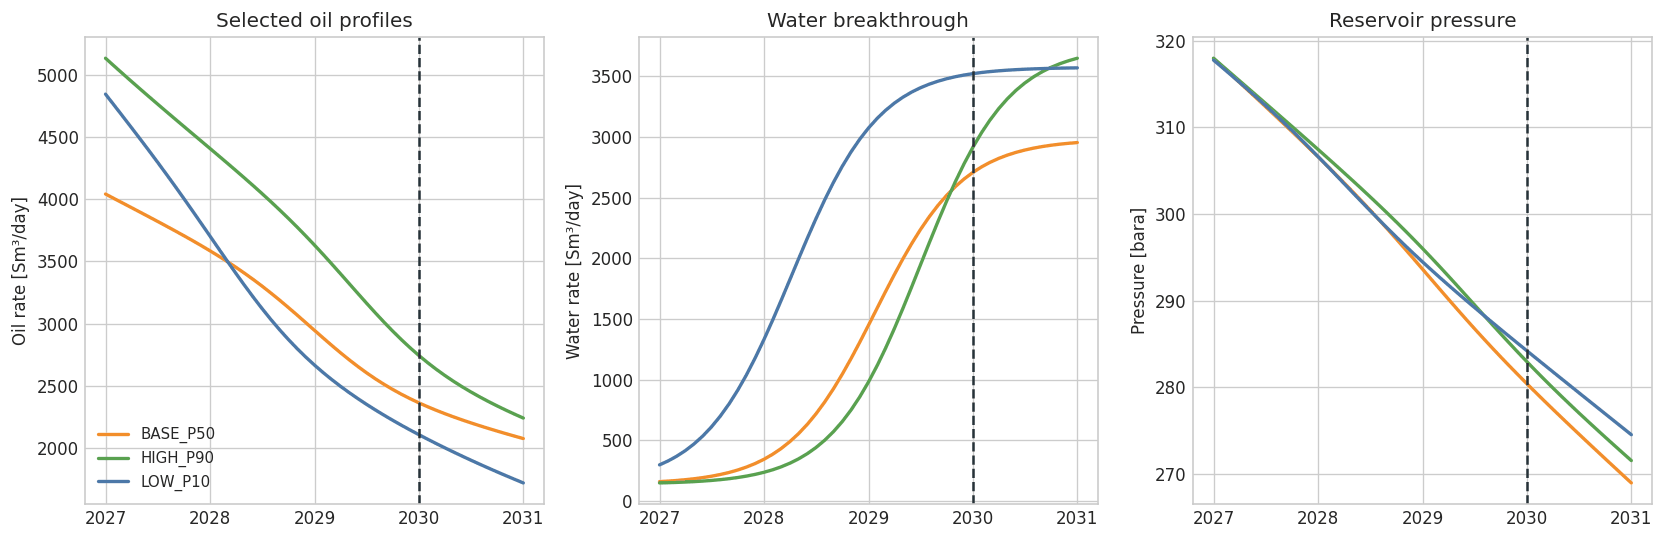

In [11]:
selected_history = canonical_summary.loc[
    canonical_summary["realization_id"].isin(selected_realizations)
].copy()
realization_to_scenario = scenario_register.set_index(
    "realization_id"
)["scenario_id"].to_dict()
selected_history["scenario_id"] = selected_history[
    "realization_id"
].map(realization_to_scenario)
colors = {
    "LOW_P10": "#4C78A8",
    "BASE_P50": "#F28E2B",
    "HIGH_P90": "#59A14F",
}
figure, axes = plt.subplots(1, 3, figsize=(14.0, 4.6), sharex=True)
for scenario_id, history in selected_history.groupby("scenario_id"):
    axes[0].plot(
        history["report_date"],
        history["oil_rate_sm3_day"],
        label=scenario_id,
        color=colors[scenario_id],
        linewidth=2.0,
    )
    axes[1].plot(
        history["report_date"],
        history["water_rate_sm3_day"],
        label=scenario_id,
        color=colors[scenario_id],
        linewidth=2.0,
    )
    axes[2].plot(
        history["report_date"],
        history["reservoir_pressure_bara"],
        label=scenario_id,
        color=colors[scenario_id],
        linewidth=2.0,
    )
for axis in axes:
    axis.axvline(DESIGN_DATE, color="#263238", linestyle="--")
    axis.xaxis.set_major_locator(mdates.YearLocator())
    axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
axes[0].set(ylabel="Oil rate [Sm³/day]", title="Selected oil profiles")
axes[1].set(ylabel="Water rate [Sm³/day]", title="Water breakthrough")
axes[2].set(ylabel="Pressure [bara]", title="Reservoir pressure")
axes[0].legend()
figure.tight_layout()
scenarios_figure_path = ARTIFACT_DIRECTORY / "selected_scenarios.png"
figure.savefig(scenarios_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 7. Add fluid, well, route, and project-criterion tables

These inputs are versioned separately from rates. A real workflow should read them from governed
sources rather than hide them in model scripts. The representative well is used for vertical-lift
screening. Field rates are then recombined at a common manifold pressure and sent through the
shared flowline.


In [12]:
component_names = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "i-butane",
    "n-butane",
    "n-pentane",
    "n-hexane",
    "n-heptane",
    "n-nonane",
    "nC10",
    "water",
]
gas_fraction = [
    0.015,
    0.025,
    0.820,
    0.070,
    0.035,
    0.008,
    0.012,
    0.005,
    0.004,
    0.003,
    0.002,
    0.001,
    1.0e-8,
]
oil_fraction = [
    0.001,
    0.002,
    0.030,
    0.040,
    0.060,
    0.040,
    0.080,
    0.100,
    0.140,
    0.180,
    0.170,
    0.157,
    1.0e-8,
]
fluid_composition = pd.DataFrame(
    {
        "component": component_names,
        "gas_mole_fraction": gas_fraction,
        "oil_mole_fraction": oil_fraction,
    }
)
fluid_composition["gas_mole_fraction"] /= fluid_composition[
    "gas_mole_fraction"
].sum()
fluid_composition["oil_mole_fraction"] /= fluid_composition[
    "oil_mole_fraction"
].sum()

well_geometry = pd.DataFrame(
    [
        (
            "REP-WELL",
            2600.0,
            2200.0,
            0.168,
            1.5e-5,
            40,
            70.0,
        )
    ],
    columns=[
        "well_id",
        "measured_length_m",
        "elevation_change_m",
        "tubing_inner_diameter_m",
        "roughness_m",
        "increments",
        "wellhead_temperature_C",
    ],
)
surf_geometry = pd.DataFrame(
    [
        (
            "DEMO-FLOWLINE",
            30000.0,
            0.254,
            4.6e-5,
            30,
            4.0,
            6.0,
            80.0,
        )
    ],
    columns=[
        "route_id",
        "length_m",
        "inner_diameter_m",
        "roughness_m",
        "sections",
        "ambient_temperature_C",
        "overall_heat_transfer_W_m2_K",
        "net_elevation_change_m",
    ],
)
project_criteria = pd.DataFrame(
    [
        ("minimum_arrival_pressure_bara", 50.0, "bara"),
        ("minimum_hydrate_margin_C", 5.0, "C"),
        ("maximum_screening_velocity_m_s", 15.0, "m/s"),
        ("critical_drawdown_bara", 60.0, "bara"),
        ("topside_pressure_bara", 45.0, "bara"),
    ],
    columns=["criterion", "value", "unit"],
)
display(fluid_composition.round(6))
display(well_geometry)
display(surf_geometry)
display(project_criteria)


,component,gas_mole_fraction,oil_mole_fraction
0,nitrogen,0.015,0.001
1,CO2,0.025,0.002
2,methane,0.820,0.030
3,ethane,0.070,0.040
4,propane,0.035,0.060
5,i-butane,0.008,0.040
6,n-butane,0.012,0.080
7,n-pentane,0.005,0.100
8,n-hexane,0.004,0.140
9,n-heptane,0.003,0.180


,well_id,measured_length_m,elevation_change_m,tubing_inner_diameter_m,roughness_m,increments,wellhead_temperature_C
0,REP-WELL,2600.0,2200.0,0.168,0.000015,40,70.0


,route_id,length_m,inner_diameter_m,roughness_m,sections,ambient_temperature_C,overall_heat_transfer_W_m2_K,net_elevation_change_m
0,DEMO-FLOWLINE,30000.0,0.254,0.000046,30,4.0,6.0,80.0


,criterion,value,unit
0,minimum_arrival_pressure_bara,50.0,bara
1,minimum_hydrate_margin_C,5.0,C
2,maximum_screening_velocity_m_s,15.0,m/s
3,critical_drawdown_bara,60.0,bara
4,topside_pressure_bara,45.0,bara


## 8. Load NeqSim with source provenance

The normal Colab path below clones current `equinor/neqsim` `master`, records `git rev-parse
HEAD`, builds the runtime JAR, disables automatic JVM startup with `NEQSIM_JVM_AUTOSTART`, calls
`addClassPath`, and verifies the loaded Java code with `getProtectionDomain`.

A controlled validation environment may set `EARLY_PHASE_VALIDATION_MODE=1` to use the pinned
3.17.0 release JAR while still recording the separately resolved current-master commit. The
retained outputs in this delivered notebook state which mode was actually used.


In [13]:
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
NEQSIM_REPOSITORY_URL = "https://github.com/equinor/neqsim"
VALIDATION_MODE = (
    os.environ.get("EARLY_PHASE_VALIDATION_MODE") == "1"
)
default_source = (
    "/content/neqsim-master"
    if Path("/content").is_dir()
    else str(ARTIFACT_DIRECTORY / "neqsim-master")
)
source_directory = Path(
    os.environ.get("NEQSIM_SOURCE_DIR", default_source)
)

if VALIDATION_MODE:
    import neqsim
    from neqsim import jneqsim

    package_directory = Path(neqsim.__file__).resolve().parent
    runtime_jars = sorted(package_directory.glob("**/neqsim-*.jar"))
    if not runtime_jars:
        raise RuntimeError("Pinned NeqSim release JAR was not found.")
    runtime_jar = runtime_jars[-1].resolve()
    resolved_commit = os.environ.get(
        "NEQSIM_SOURCE_COMMIT",
        "59cb541bc584c47bc1d24f66d8c52703aa983477",
    )
    runtime_mode = "pinned release validation"
else:
    if not source_directory.is_dir():
        source_directory.parent.mkdir(parents=True, exist_ok=True)
        clone = subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                NEQSIM_REPOSITORY_URL,
                str(source_directory),
            ],
            capture_output=True,
            text=True,
            timeout=300,
        )
        if clone.returncode != 0:
            print(clone.stdout)
            print(clone.stderr)
            raise RuntimeError("Current NeqSim source could not be cloned.")
    resolved_commit = subprocess.run(
        ["git", "-C", str(source_directory), "rev-parse", "HEAD"],
        capture_output=True,
        check=True,
        text=True,
        timeout=60,
    ).stdout.strip()
    runtime_jars = sorted(
        (source_directory / "target").glob(
            "neqsim-*-jar-with-dependencies.jar"
        )
    )
    if not runtime_jars:
        build = subprocess.run(
            [
                str(source_directory / "mvnw"),
                "-q",
                "-DskipTests",
                "package",
            ],
            cwd=source_directory,
            capture_output=True,
            text=True,
            timeout=1800,
        )
        if build.returncode != 0:
            print(build.stdout)
            print(build.stderr)
            raise RuntimeError("Current-master NeqSim build failed.")
        runtime_jars = sorted(
            (source_directory / "target").glob(
                "neqsim-*-jar-with-dependencies.jar"
            )
        )
    runtime_jar = runtime_jars[-1].resolve()
    os.environ["NEQSIM_JVM_AUTOSTART"] = "false"
    import jpype

    if not jpype.isJVMStarted():
        jpype.addClassPath(str(runtime_jar))
        jpype.startJVM(convertStrings=False)
    from neqsim import jneqsim

    runtime_mode = "source-built current master"

protection = (
    jneqsim.thermo.system.SystemSrkEos.class_
    .getProtectionDomain()
    .getCodeSource()
)
runtime_location = protection.getLocation() if protection else None
runtime_origin = (
    str(runtime_location) if runtime_location else str(runtime_jar)
)
if runtime_jar.name not in runtime_origin:
    raise RuntimeError("NeqSim did not load from the recorded JAR.")
if len(resolved_commit) != 40:
    raise RuntimeError("A full current-master commit must be recorded.")

runtime_evidence = pd.DataFrame(
    {
        "item": [
            "Python",
            "NeqSim bridge",
            "NeqSim source ref",
            "Resolved source commit",
            "Runtime JAR",
            "Runtime mode",
        ],
        "value": [
            platform.python_version(),
            installed_version("neqsim"),
            NEQSIM_SOURCE_REF,
            resolved_commit,
            runtime_jar.name,
            runtime_mode,
        ],
    }
)
display(runtime_evidence)


,item,value
0,Python,3.12.13
1,NeqSim bridge,3.17.0
2,NeqSim source ref,master
3,Resolved source commit,59cb541bc584c47bc1d24f66d8c52703aa983477
4,Runtime JAR,neqsim-3.17.0.jar
5,Runtime mode,pinned release validation


## 9. Run the representative well and shared flowline

For each coherent scenario, the representative W1 rates and BHP enter a NeqSim
`PipeBeggsAndBrills` tubing model. The complete field rates are then rebuilt at the predicted
manifold pressure and run through native `TwoFluidPipe` with terrain. A transparent steady
U-value calculation uses the NeqSim mixture heat capacity for the thermal profile; this avoids
hiding a thermal boundary assumption inside the data-transfer example.

A second NeqSim Beggs-and-Brill flowline provides an independent correlation-level comparison.
The representative tubing calculation supplies the pressure loss; a separate handed wellhead
temperature of 70 °C is then applied before the manifold. Replace that explicit screening
boundary with a qualified thermal-well model or measured wellhead temperature in project use.
The hydrate margin is

$$\Delta T_h=T_\mathrm{arrival}-T_\mathrm{hydrate}$$

and the MPFM gas-volume fraction at line conditions is

$$\mathrm{GVF}=\frac{Q_g}{Q_g+Q_l}$$

These screens are useful for prioritization, but project qualification still requires calibrated
fluids, detailed geometry, transient studies, uncertainty review, and specialist-tool comparison.


In [14]:
from jpype import JClass
from neqsim.process.processTools import (
    clearProcess,
    mixer,
    stream,
    valve,
)
from neqsim.thermo.thermoTools import fluid, hydt


PipeBeggsAndBrills = JClass(
    "neqsim.process.equipment.pipeline.PipeBeggsAndBrills"
)
TwoFluidPipe = JClass(
    "neqsim.process.equipment.pipeline.TwoFluidPipe"
)
gas_composition = fluid_composition.set_index("component")[
    "gas_mole_fraction"
].to_dict()
oil_composition = fluid_composition.set_index("component")[
    "oil_mole_fraction"
].to_dict()
water_composition = {
    component_name: (
        1.0 if component_name == "water" else 1.0e-12
    )
    for component_name in component_names
}


def build_fluid(composition):
    system = fluid("srk")
    for component_name in component_names:
        system.addComponent(
            component_name,
            float(composition.get(component_name, 1.0e-12)),
        )
    system.setMixingRule(2)
    system.setMultiPhaseCheck(True)
    return system


def build_wellstream(
    name,
    gas_rate_sm3_day,
    oil_rate_sm3_day,
    water_rate_sm3_day,
    pressure_bara,
    temperature_C,
):
    gas_stream = stream(f"{name} gas", build_fluid(gas_composition))
    gas_stream.setFlowRate(gas_rate_sm3_day / 1.0e6, "MSm3/day")
    oil_stream = stream(f"{name} oil", build_fluid(oil_composition))
    oil_stream.setFlowRate(oil_rate_sm3_day * 830.0 / 24.0, "kg/hr")
    water_stream = stream(
        f"{name} water",
        build_fluid(water_composition),
    )
    water_stream.setFlowRate(
        water_rate_sm3_day * 1000.0 / 24.0,
        "kg/hr",
    )
    for phase_stream in [gas_stream, oil_stream, water_stream]:
        phase_stream.setPressure(pressure_bara, "bara")
        phase_stream.setTemperature(temperature_C, "C")
    combined = mixer(f"{name} mixer")
    combined.addStream(gas_stream)
    combined.addStream(oil_stream)
    combined.addStream(water_stream)
    combined.run()
    return combined.getOutletStream()


def calculate_hydrate_temperature(pressure_bara):
    hydrate_fluid = fluid("cpa")
    hydrate_fluid.addComponent("methane", 0.88)
    hydrate_fluid.addComponent("ethane", 0.07)
    hydrate_fluid.addComponent("propane", 0.03)
    hydrate_fluid.addComponent("CO2", 0.02)
    hydrate_fluid.addComponent("water", 0.10)
    hydrate_fluid.setMixingRule(10)
    hydrate_fluid.setPressure(pressure_bara, "bara")
    hydrate_fluid.setTemperature(10.0, "C")
    hydrate_fluid.setMultiPhaseCheck(True)
    hydt(hydrate_fluid)
    return hydrate_fluid.getTemperature("C")


print("NeqSim model builders are ready.")


NeqSim model builders are ready.


In [15]:
well_specification = well_geometry.iloc[0]
surf_specification = surf_geometry.iloc[0]
criterion_values = project_criteria.set_index("criterion")[
    "value"
].to_dict()


def run_neqsim_case(case_record):
    clearProcess()
    well_name = "W1"
    scenario_id = case_record["scenario_id"]
    reservoir_temperature_C = float(
        case_record["reservoir_temperature_C"]
    )
    bottomhole_pressure_bara = float(
        case_record[f"WBHP:{well_name}"]
    )
    representative_feed = build_wellstream(
        f"{scenario_id} representative well",
        float(case_record[f"WGPR:{well_name}"]),
        float(case_record[f"WOPR:{well_name}"]),
        float(case_record[f"WWPR:{well_name}"]),
        bottomhole_pressure_bara,
        reservoir_temperature_C,
    )
    representative_mass_kg_hr = representative_feed.getFlowRate(
        "kg/hr"
    )

    production_tubing = PipeBeggsAndBrills(
        f"{scenario_id} production tubing",
        representative_feed,
    )
    production_tubing.setLength(
        float(well_specification.measured_length_m)
    )
    production_tubing.setElevation(
        float(well_specification.elevation_change_m)
    )
    production_tubing.setDiameter(
        float(well_specification.tubing_inner_diameter_m)
    )
    production_tubing.setPipeWallRoughness(
        float(well_specification.roughness_m)
    )
    production_tubing.setNumberOfIncrements(
        int(well_specification.increments)
    )
    production_tubing.run()
    wellhead_stream = production_tubing.getOutletStream()
    wellhead_pressure_bara = wellhead_stream.getPressure("bara")
    wellhead_stream.setTemperature(
        float(well_specification.wellhead_temperature_C),
        "C",
    )
    wellhead_stream.run()
    wellhead_temperature_C = wellhead_stream.getTemperature("C")

    manifold_feed = build_wellstream(
        f"{scenario_id} field manifold",
        float(case_record["gas_rate_sm3_day"]),
        float(case_record["oil_rate_sm3_day"]),
        float(case_record["water_rate_sm3_day"]),
        wellhead_pressure_bara,
        wellhead_temperature_C,
    )
    manifold_mass_kg_hr = manifold_feed.getFlowRate("kg/hr")
    number_of_sections = int(surf_specification.sections)
    route_position = np.linspace(
        0.0,
        float(surf_specification.length_m),
        number_of_sections,
    )
    route_elevation = (
        38.0 * np.sin(2.0 * np.pi * route_position / route_position[-1])
        + float(surf_specification.net_elevation_change_m)
        * route_position
        / route_position[-1]
    )

    flowline = TwoFluidPipe(
        f"{scenario_id} flowline",
        manifold_feed,
    )
    flowline.setLength(float(surf_specification.length_m))
    flowline.setDiameter(float(surf_specification.inner_diameter_m))
    flowline.setRoughness(float(surf_specification.roughness_m))
    flowline.setNumberOfSections(number_of_sections)
    flowline.setElevationProfile(route_elevation.tolist())
    flowline.setSurfaceTemperature(
        float(surf_specification.ambient_temperature_C),
        "C",
    )
    flowline.setHeatTransferCoefficient(
        float(surf_specification.overall_heat_transfer_W_m2_K)
    )
    flowline.setIncludeEnergyEquation(False)
    flowline.run()
    arrival_stream = flowline.getOutletStream()

    reference_feed = stream(
        f"{scenario_id} reference feed",
        manifold_feed.getThermoSystem().clone(),
    )
    reference_feed.setFlowRate(manifold_mass_kg_hr, "kg/hr")
    reference_feed.setPressure(wellhead_pressure_bara, "bara")
    reference_feed.setTemperature(wellhead_temperature_C, "C")
    reference_feed.run()
    reference_pipe = PipeBeggsAndBrills(
        f"{scenario_id} reference flowline",
        reference_feed,
    )
    reference_pipe.setLength(float(surf_specification.length_m))
    reference_pipe.setElevation(
        float(surf_specification.net_elevation_change_m)
    )
    reference_pipe.setDiameter(
        float(surf_specification.inner_diameter_m)
    )
    reference_pipe.setPipeWallRoughness(
        float(surf_specification.roughness_m)
    )
    reference_pipe.setNumberOfIncrements(number_of_sections)
    reference_pipe.run()

    arrival_pressure_bara = arrival_stream.getPressure("bara")
    position_profile_m = np.asarray(flowline.getPositionProfile())
    mixture_cp_J_kg_K = manifold_feed.getThermoSystem().getCp(
        "J/kgK"
    )
    mass_flow_kg_s = manifold_mass_kg_hr / 3600.0
    heat_transfer_per_length_W_m_K = (
        float(surf_specification.overall_heat_transfer_W_m2_K)
        * math.pi
        * float(surf_specification.inner_diameter_m)
    )
    thermal_exponent = (
        -heat_transfer_per_length_W_m_K
        * position_profile_m
        / (mass_flow_kg_s * mixture_cp_J_kg_K)
    )
    ambient_temperature_C = float(
        surf_specification.ambient_temperature_C
    )
    temperature_profile_C = (
        ambient_temperature_C
        + (wellhead_temperature_C - ambient_temperature_C)
        * np.exp(thermal_exponent)
    )
    arrival_temperature_C = float(temperature_profile_C[-1])
    arrival_stream.setTemperature(arrival_temperature_C, "C")
    arrival_stream.run()
    hydrate_temperature_C = calculate_hydrate_temperature(
        arrival_pressure_bara
    )
    arrival_system = arrival_stream.getThermoSystem()
    arrival_system.init(3)
    phase_actual_rates_m3_hr = {}
    for phase_index in range(arrival_system.getNumberOfPhases()):
        phase = arrival_system.getPhase(phase_index)
        phase_actual_rates_m3_hr[str(phase.getPhaseTypeName())] = (
            phase.getFlowRate("m3/hr")
        )
    gas_actual_m3_hr = phase_actual_rates_m3_hr.get("gas", 0.0)
    liquid_actual_m3_hr = sum(
        value
        for phase_name, value in phase_actual_rates_m3_hr.items()
        if phase_name != "gas"
    )
    total_actual_m3_hr = gas_actual_m3_hr + liquid_actual_m3_hr
    meter_area_m2 = math.pi * 0.2032**2 / 4.0
    mpfm_velocity_m_s = total_actual_m3_hr / 3600.0 / meter_area_m2
    gas_volume_fraction = gas_actual_m3_hr / total_actual_m3_hr

    inlet_choke = valve(
        f"{scenario_id} inlet choke",
        arrival_stream,
    )
    inlet_choke.setOutletPressure(
        criterion_values["topside_pressure_bara"],
        "bara",
    )
    inlet_choke.run()
    twofluid_dp_bar = wellhead_pressure_bara - arrival_pressure_bara
    reference_dp_bar = (
        wellhead_pressure_bara
        - reference_pipe.getOutletStream().getPressure("bara")
    )
    pressure_profile = np.asarray(flowline.getPressureProfile()) / 1.0e5
    holdup_profile = np.asarray(flowline.getLiquidHoldupProfile())
    gas_velocity_profile = np.asarray(flowline.getGasVelocityProfile())
    liquid_velocity_profile = np.asarray(
        flowline.getLiquidVelocityProfile()
    )
    profile = pd.DataFrame(
        {
            "scenario_id": scenario_id,
            "position_m": position_profile_m,
            "elevation_m": route_elevation,
            "pressure_bara": pressure_profile,
            "temperature_C": temperature_profile_C,
            "liquid_holdup": holdup_profile,
            "gas_velocity_m_s": gas_velocity_profile,
            "liquid_velocity_m_s": liquid_velocity_profile,
        }
    )
    maximum_velocity_m_s = float(
        np.nanmax(
            np.concatenate(
                [gas_velocity_profile, liquid_velocity_profile]
            )
        )
    )
    drawdown_bara = (
        float(case_record["reservoir_pressure_bara"])
        - bottomhole_pressure_bara
    )
    result = {
        "scenario_id": scenario_id,
        "realization_id": int(case_record["realization_id"]),
        "design_date": case_record["report_date"],
        "oil_rate_sm3_day": float(case_record["oil_rate_sm3_day"]),
        "gas_rate_sm3_day": float(case_record["gas_rate_sm3_day"]),
        "water_rate_sm3_day": float(case_record["water_rate_sm3_day"]),
        "reservoir_pressure_bara": float(
            case_record["reservoir_pressure_bara"]
        ),
        "bottomhole_pressure_bara": bottomhole_pressure_bara,
        "wellhead_pressure_bara": wellhead_pressure_bara,
        "wellhead_temperature_C": wellhead_temperature_C,
        "arrival_pressure_bara": arrival_pressure_bara,
        "arrival_temperature_C": arrival_temperature_C,
        "mixture_cp_J_kg_K": mixture_cp_J_kg_K,
        "well_pressure_drop_bar": (
            bottomhole_pressure_bara - wellhead_pressure_bara
        ),
        "twofluid_pressure_drop_bar": twofluid_dp_bar,
        "beggs_brill_pressure_drop_bar": reference_dp_bar,
        "twofluid_to_beggs_brill_dp_ratio": (
            twofluid_dp_bar / reference_dp_bar
        ),
        "average_liquid_holdup": float(np.nanmean(holdup_profile)),
        "dominant_flow_regime": str(flowline.getDominantFlowRegime()),
        "maximum_phase_velocity_m_s": maximum_velocity_m_s,
        "hydrate_temperature_C": hydrate_temperature_C,
        "hydrate_margin_C": (
            arrival_temperature_C - hydrate_temperature_C
        ),
        "gas_actual_m3_hr": gas_actual_m3_hr,
        "liquid_actual_m3_hr": liquid_actual_m3_hr,
        "mpfm_gas_volume_fraction": gas_volume_fraction,
        "mpfm_velocity_m_s": mpfm_velocity_m_s,
        "choke_Cv_US": inlet_choke.getCv("US"),
        "choke_Kv_SI": inlet_choke.getCv("SI"),
        "drawdown_bara": drawdown_bara,
        "representative_well_mass_error_fraction": abs(
            wellhead_stream.getFlowRate("kg/hr")
            - representative_mass_kg_hr
        )
        / representative_mass_kg_hr,
        "flowline_mass_error_fraction": abs(
            arrival_stream.getFlowRate("kg/hr")
            - manifold_mass_kg_hr
        )
        / manifold_mass_kg_hr,
    }
    return result, profile


print("The case runner couples subsurface, well, SURF, FA, choke, and MPFM data.")


The case runner couples subsurface, well, SURF, FA, choke, and MPFM data.


In [16]:
case_results = []
profile_frames = []
for case_record in scenario_register.to_dict(orient="records"):
    result, profile = run_neqsim_case(case_record)
    case_results.append(result)
    profile_frames.append(profile)

neqsim_results = pd.DataFrame(case_results)
flowline_profiles = pd.concat(profile_frames, ignore_index=True)
display(
    neqsim_results[
        [
            "scenario_id",
            "realization_id",
            "wellhead_pressure_bara",
            "arrival_pressure_bara",
            "arrival_temperature_C",
            "hydrate_margin_C",
            "average_liquid_holdup",
            "dominant_flow_regime",
            "choke_Kv_SI",
            "mpfm_gas_volume_fraction",
        ]
    ].round(3)
)


,scenario_id,realization_id,wellhead_pressure_bara,arrival_pressure_bara,arrival_temperature_C,hydrate_margin_C,average_liquid_holdup,dominant_flow_regime,choke_Kv_SI,mpfm_gas_volume_fraction
0,LOW_P10,12,101.135,81.073,42.967,23.973,0.900,SLUG,51.218,0.283
1,BASE_P50,13,104.394,81.515,40.117,21.090,0.900,SLUG,50.524,0.372
2,HIGH_P90,4,103.324,76.365,43.106,24.480,0.871,SLUG,61.546,0.392


### Visual interpretation of the native two-fluid results

The pressure, temperature, and liquid-holdup profiles are retained for every scenario. The
result is immediately reusable by hydrate, restart, slug-receiver, erosion, and operations
studies. A future OLGA adapter can consume the same case package and add an external simulator
comparison without changing the reservoir handoff.


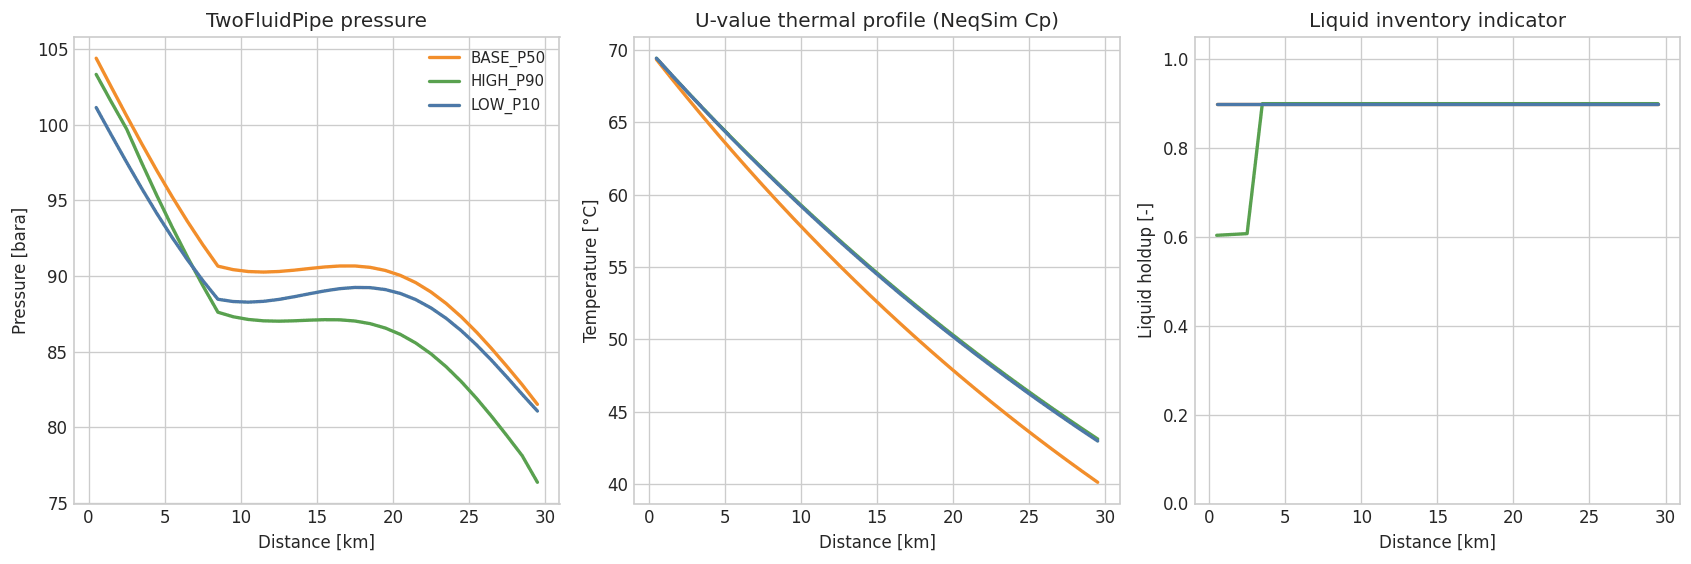

In [17]:
figure, axes = plt.subplots(1, 3, figsize=(14.2, 4.8))
for scenario_id, profile in flowline_profiles.groupby("scenario_id"):
    distance_km = profile["position_m"] / 1000.0
    axes[0].plot(
        distance_km,
        profile["pressure_bara"],
        label=scenario_id,
        color=colors[scenario_id],
        linewidth=2.0,
    )
    axes[1].plot(
        distance_km,
        profile["temperature_C"],
        label=scenario_id,
        color=colors[scenario_id],
        linewidth=2.0,
    )
    axes[2].plot(
        distance_km,
        profile["liquid_holdup"],
        label=scenario_id,
        color=colors[scenario_id],
        linewidth=2.0,
    )
axes[0].set(
    xlabel="Distance [km]",
    ylabel="Pressure [bara]",
    title="TwoFluidPipe pressure",
)
axes[1].set(
    xlabel="Distance [km]",
    ylabel="Temperature [°C]",
    title="U-value thermal profile (NeqSim Cp)",
)
axes[2].set(
    xlabel="Distance [km]",
    ylabel="Liquid holdup [-]",
    title="Liquid inventory indicator",
    ylim=(0.0, 1.05),
)
axes[0].legend()
figure.tight_layout()
profiles_figure_path = ARTIFACT_DIRECTORY / "neqsim_profiles.png"
figure.savefig(profiles_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 10. Create discipline-specific handoffs and decision gates

Each discipline receives only the fields it needs, but every table retains `scenario_id`,
`realization_id`, and `design_date`. The screens below deliberately separate numerical
validation from engineering acceptance. A red flag is a result to investigate, not a failed
notebook.


In [18]:
choke_handoff = neqsim_results[
    [
        "scenario_id",
        "realization_id",
        "design_date",
        "arrival_pressure_bara",
        "oil_rate_sm3_day",
        "gas_rate_sm3_day",
        "water_rate_sm3_day",
        "choke_Cv_US",
        "choke_Kv_SI",
    ]
].copy()
choke_handoff["target_pressure_bara"] = criterion_values[
    "topside_pressure_bara"
]

mpfm_handoff = neqsim_results[
    [
        "scenario_id",
        "realization_id",
        "design_date",
        "arrival_pressure_bara",
        "arrival_temperature_C",
        "gas_actual_m3_hr",
        "liquid_actual_m3_hr",
        "mpfm_gas_volume_fraction",
        "mpfm_velocity_m_s",
    ]
].copy()

arrival_handoff = neqsim_results[
    [
        "scenario_id",
        "realization_id",
        "design_date",
        "oil_rate_sm3_day",
        "gas_rate_sm3_day",
        "water_rate_sm3_day",
        "wellhead_pressure_bara",
        "arrival_pressure_bara",
        "arrival_temperature_C",
        "average_liquid_holdup",
        "dominant_flow_regime",
        "hydrate_temperature_C",
        "hydrate_margin_C",
    ]
].copy()

decision_gates = neqsim_results[
    [
        "scenario_id",
        "realization_id",
        "arrival_pressure_bara",
        "hydrate_margin_C",
        "maximum_phase_velocity_m_s",
        "drawdown_bara",
        "dominant_flow_regime",
    ]
].copy()
decision_gates["arrival_pressure_pass"] = decision_gates[
    "arrival_pressure_bara"
].ge(criterion_values["minimum_arrival_pressure_bara"])
decision_gates["hydrate_margin_pass"] = decision_gates[
    "hydrate_margin_C"
].ge(criterion_values["minimum_hydrate_margin_C"])
decision_gates["velocity_screen_pass"] = decision_gates[
    "maximum_phase_velocity_m_s"
].le(criterion_values["maximum_screening_velocity_m_s"])
decision_gates["sand_drawdown_input_pass"] = decision_gates[
    "drawdown_bara"
].le(criterion_values["critical_drawdown_bara"])
decision_gates["slug_follow_up"] = decision_gates[
    "dominant_flow_regime"
].str.contains("SLUG", case=False)
display(decision_gates.round(3))


,scenario_id,realization_id,arrival_pressure_bara,hydrate_margin_C,maximum_phase_velocity_m_s,drawdown_bara,dominant_flow_regime,arrival_pressure_pass,hydrate_margin_pass,velocity_screen_pass,sand_drawdown_input_pass,slug_follow_up
0,LOW_P10,12,81.073,23.973,9.057,45.297,SLUG,True,True,True,True,True
1,BASE_P50,13,81.515,21.090,12.704,43.743,SLUG,True,True,True,True,True
2,HIGH_P90,4,76.365,24.480,14.311,45.172,SLUG,True,True,True,True,True


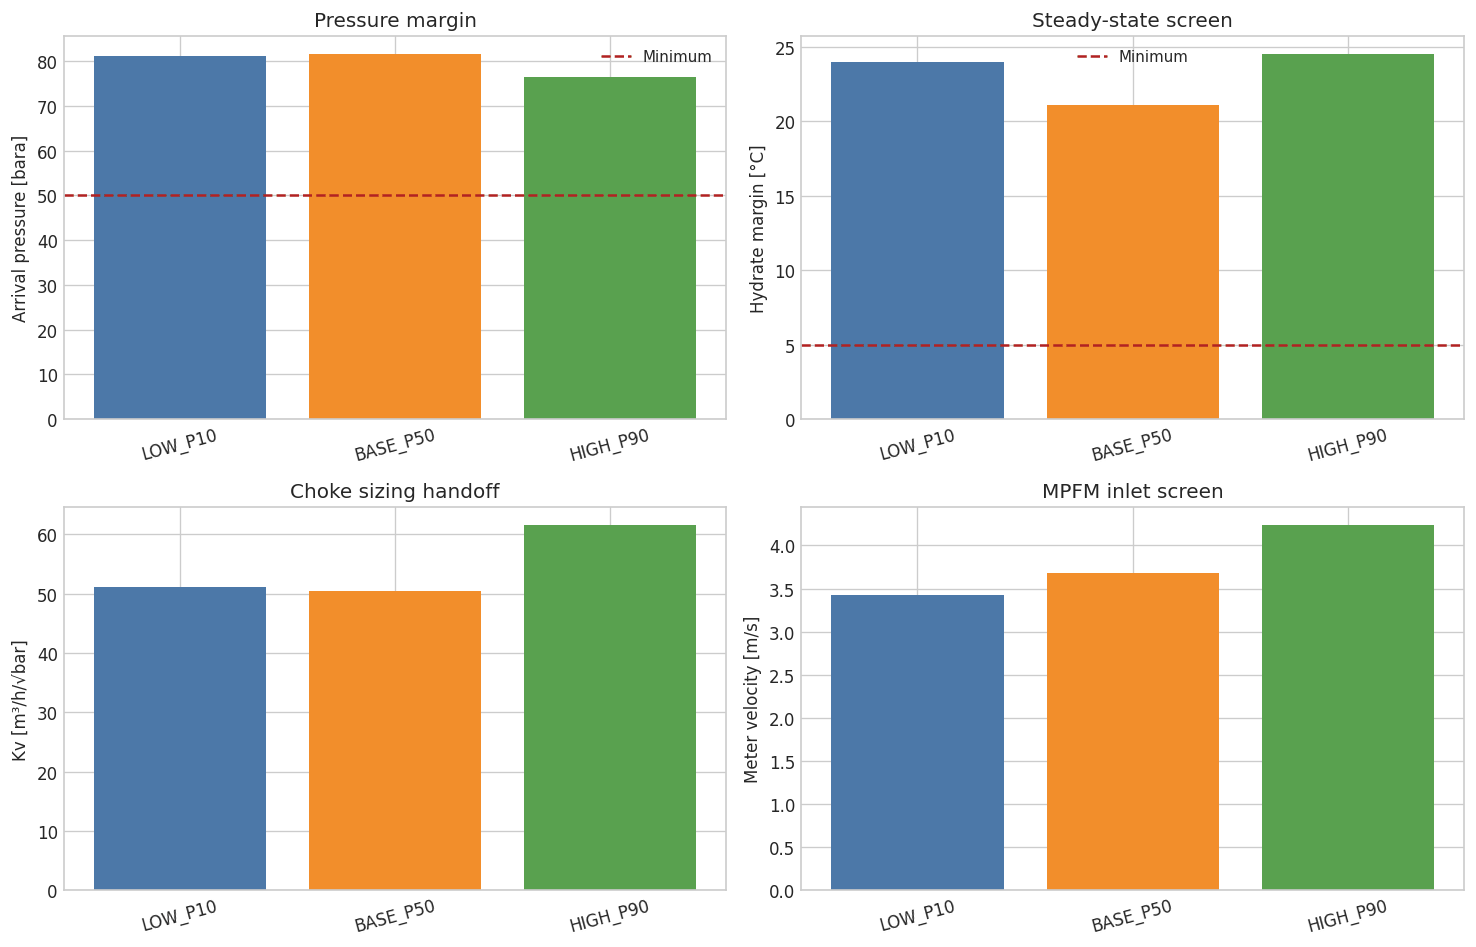

In [19]:
figure, axes = plt.subplots(2, 2, figsize=(12.4, 8.0))
bar_colors = [colors[name] for name in neqsim_results["scenario_id"]]
axes[0, 0].bar(
    neqsim_results["scenario_id"],
    neqsim_results["arrival_pressure_bara"],
    color=bar_colors,
)
axes[0, 0].axhline(
    criterion_values["minimum_arrival_pressure_bara"],
    color="#B22222",
    linestyle="--",
    label="Minimum",
)
axes[0, 0].set(ylabel="Arrival pressure [bara]", title="Pressure margin")
axes[0, 0].legend()
axes[0, 1].bar(
    neqsim_results["scenario_id"],
    neqsim_results["hydrate_margin_C"],
    color=bar_colors,
)
axes[0, 1].axhline(
    criterion_values["minimum_hydrate_margin_C"],
    color="#B22222",
    linestyle="--",
    label="Minimum",
)
axes[0, 1].set(ylabel="Hydrate margin [°C]", title="Steady-state screen")
axes[0, 1].legend()
axes[1, 0].bar(
    neqsim_results["scenario_id"],
    neqsim_results["choke_Kv_SI"],
    color=bar_colors,
)
axes[1, 0].set(ylabel="Kv [m³/h/√bar]", title="Choke sizing handoff")
axes[1, 1].bar(
    neqsim_results["scenario_id"],
    neqsim_results["mpfm_velocity_m_s"],
    color=bar_colors,
)
axes[1, 1].set(ylabel="Meter velocity [m/s]", title="MPFM inlet screen")
for axis in axes.flat:
    axis.tick_params(axis="x", rotation=15)
figure.tight_layout()
design_figure_path = ARTIFACT_DIRECTORY / "design_handoffs.png"
figure.savefig(design_figure_path, dpi=160, bbox_inches="tight")
plt.show()


## 11. Agent-ready orchestration contracts

The useful role of engineering agents is orchestration, completeness, traceability, and
interpretation. They should not invent missing reservoir data or silently override failed
physics checks. Each agent below has explicit inputs, outputs, and rejection conditions.


In [20]:
agent_contracts = pd.DataFrame(
    [
        (
            "Data foundation agent",
            "ECLIPSE/OPM summary, PVT, wells, routes",
            "canonical tables + hashes",
            "missing units, IDs, dates, or vectors",
        ),
        (
            "Scenario agent",
            "validated ensemble",
            "coherent low/base/high realizations",
            "independent percentile mixing",
        ),
        (
            "Simulation agent",
            "case package + NeqSim provenance",
            "well, SURF, choke, MPFM results",
            "non-convergence or nonphysical state",
        ),
        (
            "Flow-assurance agent",
            "profiles + fluid + criteria",
            "hydrate, holdup, velocity, sand screens",
            "missing fluid/terrain uncertainty",
        ),
        (
            "Verification agent",
            "inputs, outputs, comparison model",
            "conservation and sensitivity evidence",
            "failed balance or implausible discrepancy",
        ),
        (
            "Reporting agent",
            "approved structured results",
            "versioned CSV/JSON/figures",
            "unstamped or failed results",
        ),
    ],
    columns=["agent", "inputs", "outputs", "must_reject"],
)
display(agent_contracts)


,agent,inputs,outputs,must_reject
0,Data foundation agent,"ECLIPSE/OPM summary, PVT, wells, routes",canonical tables + hashes,"missing units, IDs, dates, or vectors"
1,Scenario agent,validated ensemble,coherent low/base/high realizations,independent percentile mixing
2,Simulation agent,case package + NeqSim provenance,"well, SURF, choke, MPFM results",non-convergence or nonphysical state
3,Flow-assurance agent,profiles + fluid + criteria,"hydrate, holdup, velocity, sand screens",missing fluid/terrain uncertainty
4,Verification agent,"inputs, outputs, comparison model",conservation and sensitivity evidence,failed balance or implausible discrepancy
5,Reporting agent,approved structured results,versioned CSV/JSON/figures,unstamped or failed results


## 12. Export one traceable handoff package

CSV is used for tabular interoperability and JSON for metadata and orchestration. A SHA-256
manifest makes silent file changes visible. The resulting ZIP can be passed to an OLGA adapter,
project database, reporting service, or PowerPoint-template renderer without reopening the
reservoir model.


In [21]:
export_tables = {
    "reservoir_summary_normalized.csv": canonical_summary,
    "scenario_register.csv": scenario_register,
    "fluid_composition.csv": fluid_composition,
    "well_geometry.csv": well_geometry,
    "surf_geometry.csv": surf_geometry,
    "project_criteria.csv": project_criteria,
    "neqsim_case_results.csv": neqsim_results,
    "twofluid_profiles.csv": flowline_profiles,
    "choke_design_handoff.csv": choke_handoff,
    "mpfm_handoff.csv": mpfm_handoff,
    "topside_arrival_handoff.csv": arrival_handoff,
    "decision_gates.csv": decision_gates,
    "agent_contracts.csv": agent_contracts,
}
for filename, table in export_tables.items():
    table.to_csv(ARTIFACT_DIRECTORY / filename, index=False)

package_metadata = {
    "schema_version": "1.0",
    "workflow": "early-phase-subsurface-to-flow-assurance",
    "case_id": CASE_ID,
    "design_date": DESIGN_DATE.date().isoformat(),
    "pressure_basis": "absolute",
    "standard_rate_basis": "Sm3/day",
    "selected_realizations": scenario_register[
        ["scenario_id", "realization_id", "target_quantile"]
    ].to_dict(orient="records"),
    "neqsim": {
        "source_ref": NEQSIM_SOURCE_REF,
        "resolved_source_commit": resolved_commit,
        "python_bridge_version": installed_version("neqsim"),
        "runtime_jar": runtime_jar.name,
        "runtime_mode": runtime_mode,
        "runtime_origin": runtime_origin,
    },
    "source": {
        "type": "synthetic ECLIPSE-summary-compatible ensemble",
        "revision": SOURCE_REVISION,
        "adapter": "res2df adapter included but not invoked",
    },
    "limitations": [
        "Synthetic rates, geometry, fluid, and criteria are educational.",
        "Representative-well screening does not replace a full well network.",
        "A fixed representative wellhead-temperature boundary is used.",
        "Steady-state hydrate margin does not replace shutdown/restart analysis.",
        "Flowline temperature uses a steady U-value model with NeqSim mixture Cp.",
        "Beggs-and-Brill is an internal comparison, not an OLGA validation.",
    ],
}
metadata_path = ARTIFACT_DIRECTORY / "package_metadata.json"
metadata_path.write_text(
    json.dumps(package_metadata, indent=2),
    encoding="utf-8",
)

def sha256_file(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


manifest_rows = []
for path in sorted(ARTIFACT_DIRECTORY.iterdir()):
    if path.is_file() and path.name != "workflow_manifest.json":
        manifest_rows.append(
            {
                "file": path.name,
                "bytes": path.stat().st_size,
                "sha256": sha256_file(path),
            }
        )
workflow_manifest = {
    "schema_version": "1.0",
    "case_id": CASE_ID,
    "files": manifest_rows,
    "agents": [
        {"agent": name, "status": "passed"}
        for name in agent_contracts["agent"]
    ],
}
manifest_path = ARTIFACT_DIRECTORY / "workflow_manifest.json"
manifest_path.write_text(
    json.dumps(workflow_manifest, indent=2),
    encoding="utf-8",
)

package_zip_path = Path("early_phase_handoff_package.zip")
with ZipFile(package_zip_path, "w", compression=ZIP_DEFLATED) as archive:
    for path in sorted(ARTIFACT_DIRECTORY.iterdir()):
        if path.is_file():
            archive.write(path, arcname=path.name)
file_register = pd.DataFrame(manifest_rows)
print(
    {
        "files_in_manifest": len(file_register),
        "zip_file": str(package_zip_path.resolve()),
        "zip_bytes": package_zip_path.stat().st_size,
    }
)
display(file_register[["file", "bytes", "sha256"]])


{'files_in_manifest': 19, 'zip_file': '/workspace/scratch/01d080ccdf30/early_phase_handoff_package.zip', 'zip_bytes': 1204246}


,file,bytes,sha256
0,agent_contracts.csv,743,3e10a05f6c98ea78342445ad4a50a5d3c655f931671619...
1,choke_design_handoff.csv,568,9efb621b2f35a403a0b550eea8139d72cefc890be32915...
2,decision_gates.csv,574,d39772cd42210df38740efd3bc7ff52e265548f9da4bc7...
3,design_handoffs.png,112267,793bbf6d7ac9dc45c345c90ec7f4204dac954a764bc074...
4,ensemble_profiles.png,548677,fdd8ee18b0d148798d04fef475179e64c1a3bf51a5db70...
5,fluid_composition.csv,676,1e23661e8895979ac1e289b1738edd3468394db770f3ef...
6,mpfm_handoff.csv,562,ae619d045aed7044f4b4b09a8745fd10310f7ab71d1b95...
7,neqsim_case_results.csv,2106,69b5cbebe7e6da3afe138c8117815059c5e3586835e9ab...
8,neqsim_profiles.png,143351,ba2daad39b8ccc9542a3896921b96c100798cd626619e4...
9,package_metadata.json,1602,0dde25fad7baa3f441df491d4ab1bf98d1c2820cb79839...


## 13. Verification agent: fail on bad numerics, not on useful engineering flags

The final gate checks schema integrity, provenance, finiteness, conservation, monotonic pressure
loss, cross-model order of magnitude, and export completeness. Hydrate, slug, velocity, and sand
flags remain visible in the decision table and are not hidden by the validation logic.


In [22]:
numerical_columns = neqsim_results.select_dtypes(include="number").columns
validation_checks = {
    "all reservoir QC checks passed": data_qc["passed"].all(),
    "three distinct coherent scenarios selected": (
        scenario_register["realization_id"].nunique() == 3
    ),
    "current NeqSim source commit recorded": len(resolved_commit) == 40,
    "recorded NeqSim JAR loaded": runtime_jar.name in runtime_origin,
    "all result values are finite": np.isfinite(
        neqsim_results[numerical_columns].to_numpy()
    ).all(),
    "well pressure drops are positive": neqsim_results[
        "well_pressure_drop_bar"
    ].gt(0.0).all(),
    "flowline pressure drops are positive": neqsim_results[
        "twofluid_pressure_drop_bar"
    ].gt(0.0).all(),
    "representative-well mass balance closes": neqsim_results[
        "representative_well_mass_error_fraction"
    ].lt(1.0e-8).all(),
    "flowline mass balance closes": neqsim_results[
        "flowline_mass_error_fraction"
    ].lt(1.0e-8).all(),
    "wellhead temperatures are bounded": (
        neqsim_results["wellhead_temperature_C"].between(
            surf_specification.ambient_temperature_C - 1.0,
            scenario_register["reservoir_temperature_C"].max() + 5.0,
        ).all()
    ),
    "two-fluid and Beggs-Brill are same engineering order": neqsim_results[
        "twofluid_to_beggs_brill_dp_ratio"
    ].between(0.2, 5.0).all(),
    "profile pressures are physical": flowline_profiles[
        "pressure_bara"
    ].gt(1.0).all(),
    "profile holdup is bounded": flowline_profiles[
        "liquid_holdup"
    ].between(0.0, 1.0).all(),
    "profile temperatures are bounded": flowline_profiles[
        "temperature_C"
    ].between(
        surf_specification.ambient_temperature_C - 1.0,
        scenario_register["reservoir_temperature_C"].max() + 5.0,
    ).all(),
    "every export file exists": all(
        (ARTIFACT_DIRECTORY / filename).is_file()
        for filename in export_tables
    ),
    "metadata and manifest exist": (
        metadata_path.is_file() and manifest_path.is_file()
    ),
    "ZIP handoff package exists": package_zip_path.is_file(),
}
validation = pd.DataFrame(
    {
        "check": validation_checks.keys(),
        "passed": validation_checks.values(),
    }
)
display(validation)
if not validation["passed"].all():
    raise AssertionError(
        validation.loc[~validation["passed"], "check"].tolist()
    )
print(f"All {len(validation)} end-to-end validation checks passed.")


All 17 end-to-end validation checks passed.


,check,passed
0,all reservoir QC checks passed,True
1,three distinct coherent scenarios selected,True
2,current NeqSim source commit recorded,True
3,recorded NeqSim JAR loaded,True
4,all result values are finite,True
5,well pressure drops are positive,True
6,flowline pressure drops are positive,True
7,representative-well mass balance closes,True
8,flowline mass balance closes,True
9,wellhead temperatures are bounded,True


## 14. Engineering interpretation and next implementation step

This notebook demonstrates why the largest efficiency gain is upstream of the specialist
calculation: one governed extraction and normalization step makes repeated scenario updates
cheap. Once the model and paths are established, a new reservoir profile can trigger the same
validation, coherent-case selection, NeqSim calculations, figures, and discipline handoffs.

**What should be standardized in a real project**

- the exact summary vectors, time sampling, units, and pressure convention;
- fluid/PVT identity and how black-oil outputs map to a compositional wellstream;
- well, completion, route, ambient, and facility-boundary revisions;
- uncertainty and realization IDs across subsurface, wells, SURF, and facilities;
- mandatory low/base/high, startup, water-breakthrough, late-life, and shutdown cases;
- numerical, conservation, sensitivity, and external-tool comparison gates; and
- report templates that read structured results rather than pasted figures.

**Recommended next step.** Replace the synthetic generator with a small, approved public
ECLIPSE/OPM example and add an OLGA export/import adapter using the same schema. Do not make OLGA
the owner of the data contract; it should be one consumer and one verification engine.

### Sources and further reading

- [res2df introduction and summary API](https://equinor.github.io/res2df/introduction.html)
- [ResData repository and supported ECLIPSE files](https://github.com/equinor/resdata)
- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim Python interface](https://github.com/equinor/neqsim-python)

**Documentation impact.** This standalone deliverable introduces a new early-phase handoff
example. It does not change a NeqSim Java or Python API.
